## 1. Project Overview
This notebook summarizes the Bitcoin Time Series project.
It compiles data ingestion, preprocessing, EDA, and forecasting (ARIMA, SARIMA, Symbolic)
into one final, visual report.

/tmp/ipykernel_4947/4225109482.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_hourly['price_usd'].resample('1H').mean().dropna()


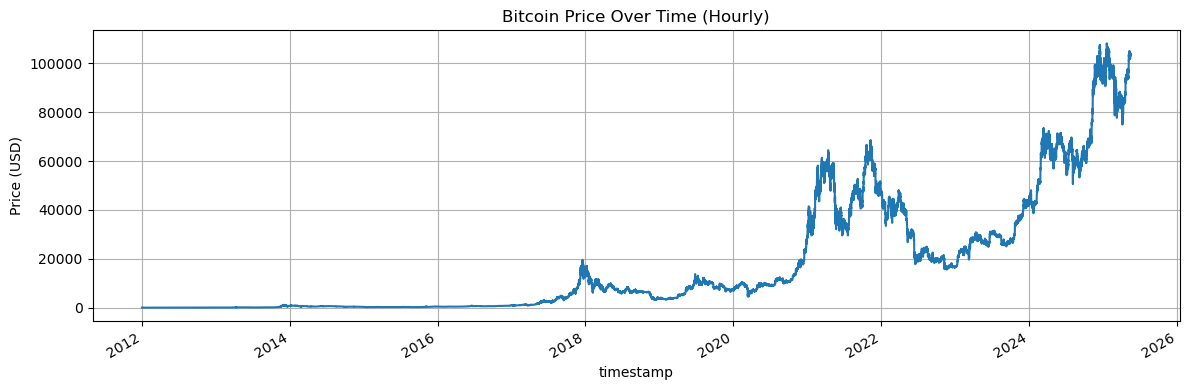

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned hourly price data
df_hourly = pd.read_csv('../data/bitcoin_timeseries.csv', parse_dates=['timestamp'], index_col='timestamp')
df_hourly = df_hourly['price_usd'].resample('1H').mean().dropna()

plt.figure(figsize=(12, 4))
df_hourly.plot(title='Bitcoin Price Over Time (Hourly)', ylabel='Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
comparison_df = pd.read_csv('../data/bitcoin_forecast_comparison.csv')
comparison_df['timestamp'] = pd.to_datetime(comparison_df['timestamp'])

plt.figure(figsize=(12, 4))
plt.plot(comparison_df['timestamp'], comparison_df['arima_pred'], label='ARIMA')
plt.plot(comparison_df['timestamp'], comparison_df['sarima_pred'], label='SARIMA')
plt.title('ARIMA vs SARIMA Forecast')
plt.xlabel('Timestamp')
plt.ylabel('Forecasted Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: 'arima_pred'

<Figure size 1200x400 with 0 Axes>

In [ ]:
try:
    df_symbolic = pd.read_csv('../reports/symbolic_forecast.csv')
    df_symbolic['timestamp'] = pd.to_datetime(df_symbolic['timestamp'])
    plt.figure(figsize=(12, 4))
    plt.plot(df_symbolic['timestamp'], df_symbolic['forecast'], label='Symbolic', color='green')
    plt.title('Symbolic Regression Forecast')
    plt.xlabel('Timestamp')
    plt.ylabel('Forecasted Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print("Symbolic forecast file not found.")

## 5. Visual Summary from Reports Folder

In [ ]:
from IPython.display import Image, display
display(Image("../reports/arima_vs_sarima_comparison.png"))
display(Image("../reports/symbolic_forecast_polynomial_fit.png"))
display(Image("../reports/zoomed_recent_60_30_days.png"))
display(Image("../reports/rolling_averages.png"))
display(Image("../reports/volatility_rolling_stddev.png"))

## 6. Final Observations
- Bitcoin price is volatile and non-stationary, requiring careful modeling.
- Symbolic modeling produced interpretable, closed-form equations.
- ARIMA gave quick forecasts but missed seasonality.
- SARIMA handled cyclic behavior better with improved residuals.
- Visual comparisons show SARIMA as the best overall performer.

**Next Steps:**
- Integrate live updates into modeling.
- Automate symbolic forecasting with genetic search.
- Build real-time dashboard/reporting system.